This is the notebook where I construct a basic pipeline as follows:

1) Query a dataset from the Materials Project using a element pairing of Pb and I: note, 
perovskites include more pairings than this. We just use these two to keep things simple to start

2) Edit the data into manipulatable forms for downstream training/testing usage.

3) Train and test the model, visualize performance.

STEP 1: Database query + visualization

In [2]:
from mp_api.client import MPRester
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os
load_dotenv()
API_KEY = os.getenv("MP_API_KEY")

# Define the halide perovskite families we want to query
# We are specifically interested in the lead halide perovskites
with MPRester(API_KEY) as mpr:
    docs = mpr.materials.summary.search(
        elements=["Pb", "I"],           # halide perovskites — start with Pb-I family
        band_gap=(0.5, 3.0),
        fields=[
            "formula_pretty",
            "band_gap",
            "energy_above_hull",
            "formation_energy_per_atom",
            "volume",
            "density",
            "nsites"
        ]
    )

#After obtaining the data we want to convert it to a more usable form for matplotlib and pandas. 
#We create a list, data, where each entry is a MPDataDoc object containing relevant properties of each material obtianed byt he query
#because not all materials will have all the desired properties, we use getattr setting a default value of None for missing attributes.
#If this was not done, wed encoutner an error when assembling our dataframe, and pandas would not be able to handle the missing data well.
data = []
for doc in docs:
    data.append({
        "formula": doc.formula_pretty,
        "band_gap": getattr(doc, "band_gap", None),
        "energy_above_hull": getattr(doc, "energy_above_hull", None),
        "formation_energy": getattr(doc, "formation_energy_per_atom", None),
        "volume": getattr(doc, "volume", None),
        "density": getattr(doc, "density", None),
        "nsites": getattr(doc, "nsites", None)
    })

#Converting the list of dictionaries into a pandas DataFrame makes dana manipulation and usage much more convenient
df = pd.DataFrame(data)

# Drop rows where key columns are missing
df = df.dropna(subset=["band_gap", "energy_above_hull"])

print(f"Found {len(df)} materials after cleaning")
print(df.head())
print("\nMissing values per column:")
print(df.isnull().sum())



Retrieving SummaryDoc documents:   0%|          | 0/89 [00:00<?, ?it/s]

Found 89 materials after cleaning
      formula  band_gap  energy_above_hull  formation_energy       volume  \
0    NaPb2IO6    2.6086           0.040496         -1.335463   142.155223   
1     HPb2IO2    2.3274           0.092941         -1.192513   317.570602   
2  H6PbC3S2IN    2.8510           0.145013         -0.269725   971.279590   
3  H8PbC5S2IN    2.9546           0.125306         -0.232263  1178.374986   
4   P3Pb5IO12    2.4246           0.033441         -2.200603   698.899020   

    density  nsites  
0  7.712966      10  
1  6.006011      12  
2  3.106902      56  
3  2.707639      72  
4  6.879847      42  

Missing values per column:
formula              0
band_gap             0
energy_above_hull    0
formation_energy     0
volume               0
density              0
nsites               0
dtype: int64


Next, we plot our data.

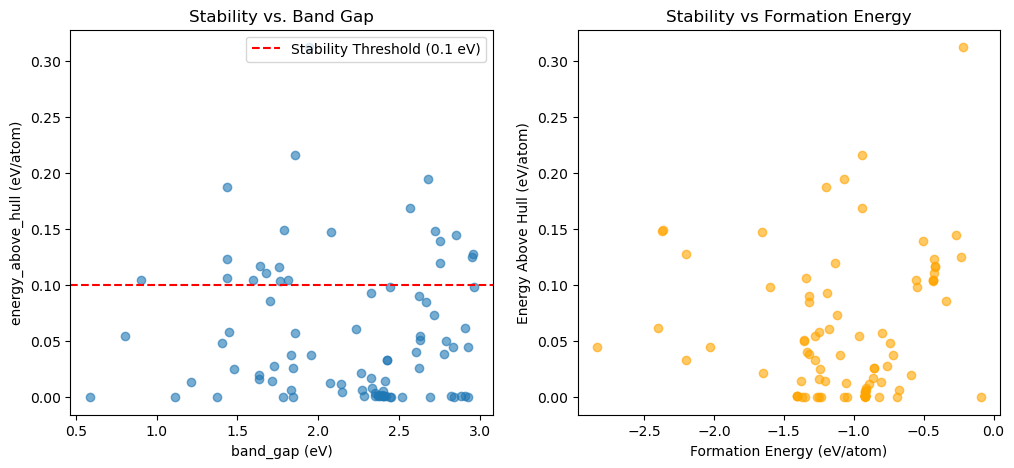

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize= (12,5))

#band gap vs stability
axes[0].scatter(df["band_gap"], df["energy_above_hull"], alpha = 0.6)
axes[0].set_xlabel("band_gap (eV)")
axes[0].set_ylabel("energy_above_hull (eV/atom)")
axes[0].set_title("Stability vs. Band Gap")

#A common threshold for stability is an energy above hull of about 0.1 eV/atom
#so we can add a threshold line to visualize where materials fall in terms of stability
axes[0].axhline(y = 0.1, color = "r", linestyle = "--", label = "Stability Threshold (0.1 eV)")
axes[0].legend()

# Formation energy vs stability
axes[1].scatter(df["formation_energy"], df["energy_above_hull"], alpha=0.6, color='orange')
axes[1].set_xlabel("Formation Energy (eV/atom)")
axes[1].set_ylabel("Energy Above Hull (eV/atom)")
axes[1].set_title("Stability vs Formation Energy")

plt.show()

The Plot on the left gives us visualization of the energy above hull vs the band gap voltage, whereas the plot on the right gives a energy above hull vs. formation energy.

Energy Above Hull itself gives us a measurement of a composition's stability. We want low Energy above Hull because that gives us the best possible candidates for stable, synthesizable candidates. 

After getting oriented tiwth querying data from the Materials Project, its time to do some proper analysis. The first step we have to do, is convert our chemical formulas (which are currently just strings) into a usable form where the

STEP 2: Data cleaning + Featurization

In [4]:
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition

# Step 1: convert formula strings into pymatgen Composition objects
# matminer needs this format to work with chemical formulas
str_to_comp = StrToComposition()
df = str_to_comp.featurize_dataframe(df, "formula", ignore_errors=True)

# Step 2: generate compositional features from the Composition column
# ElementProperty pulls statistics (mean, std, min, max, range) across all 
# elements in a formula for properties like electronegativity, atomic radius,
# ionization energy, etc.
# MAGPIE (Materials Agnostic Platform for Informatics and Exploration) 
# is a widely used set of 22 elemental properties such as those listed above
ep_featurizer = ElementProperty.from_preset("magpie")
df = ep_featurizer.featurize_dataframe(df, col_id="composition", ignore_errors=True)

print(f"DataFrame now has {df.shape[1]} columns")
print(df.head())


StrToComposition:   0%|          | 0/89 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/89 [00:00<?, ?it/s]

DataFrame now has 140 columns
      formula  band_gap  energy_above_hull  formation_energy       volume  \
0    NaPb2IO6    2.6086           0.040496         -1.335463   142.155223   
1     HPb2IO2    2.3274           0.092941         -1.192513   317.570602   
2  H6PbC3S2IN    2.8510           0.145013         -0.269725   971.279590   
3  H8PbC5S2IN    2.9546           0.125306         -0.232263  1178.374986   
4   P3Pb5IO12    2.4246           0.033441         -2.200603   698.899020   

    density  nsites          composition  MagpieData minimum Number  \
0  7.712966      10       (Na, Pb, I, O)                        8.0   
1  6.006011      12        (H, Pb, I, O)                        1.0   
2  3.106902      56  (H, Pb, C, S, I, N)                        1.0   
3  2.707639      72  (H, Pb, C, S, I, N)                        1.0   
4  6.879847      42        (P, Pb, I, O)                        8.0   

   MagpieData maximum Number  ...  MagpieData range GSmagmom  \
0               

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

#First we want to drop all non-numeric and non-featrue columns from our dataframe
#as these cannot be used to train the model
exclude_cols = ["formula", "composition", "energy_above_hull", "band_gap",
"formation_energy", "volume", "density", "nsites"]
feature_cols = [col for col in df.columns if col not in exclude_cols]

# Remove any rows with NaN in features
df_clean = df.dropna(subset = feature_cols  + ["energy_above_hull"])

#X is the features that we have an input for and y is our target value that we want to predict
#y, the energy above hull, is as indicated earlier, a common metric for stability
#By using 
X = df_clean[feature_cols]
y = df_clean["energy_above_hull"]

print(f"Post-cleaning, we are now training on {X.shape[0]} materials with {X.shape[1]} features")

Post-cleaning, we are now training on 89 materials with 132 features


After cleaning our data, time to move onto training. We are using a random forest regressor and are using a 80/20 train/test split. 

STEP 3: Training the model, and plotting results

In [6]:
# split our data into the test and training sets using 80/20 split
# X_train, X_test are our split datasets for the input features given by X
# y_train, y_test are the corresponding target values for the training and testing sets respectively 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Display number of samples in training and testing sets
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# Train the model: Here we create 100 different trees for the random forest,
# and set a random state for reproducability
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf.fit(X_train, y_train)

# Evaluate
# Using the trained model, we take our testing data, X_test, and predict the energy above hull values, y_pred
# We then compare these predicted values against the actual test values, y_test, and claculate r^2 values and mean absolute error.
y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Finally, we print out our evaluation of the model's accuracy 
print(f"Mean Absolute Error: {mae:.4f} eV/atom")
print(f"R² Score: {r2:.4f}")

Training set: 71 samples
Testing set: 18 samples
Mean Absolute Error: 0.0270 eV/atom
R² Score: 0.1723


Now that we have trained the model and established its accuracy, its time to plot the results.

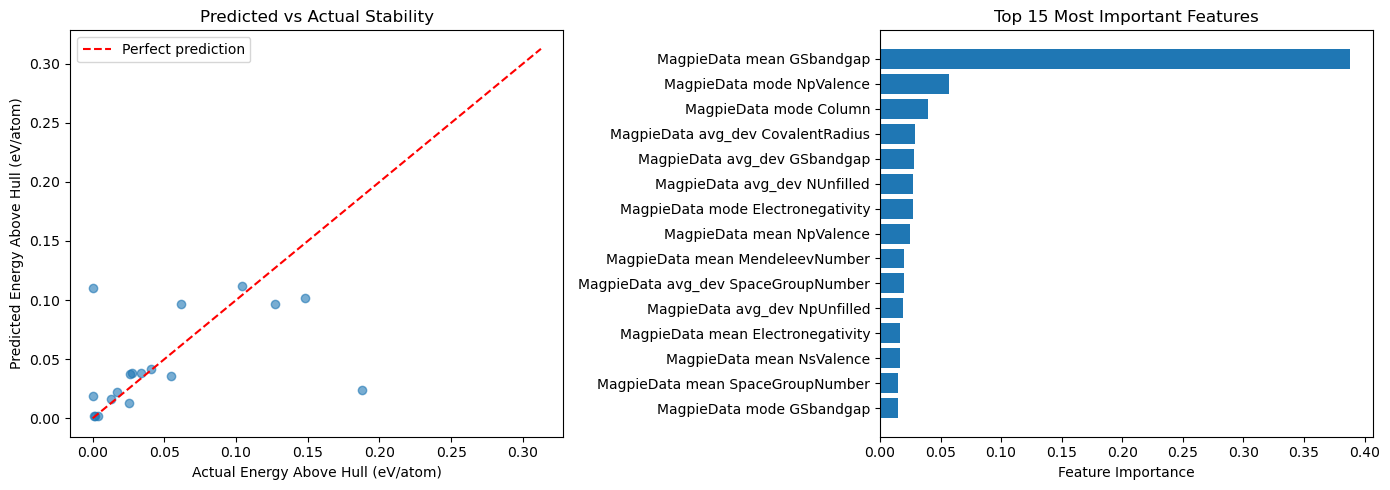

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.6)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
axes[0].set_xlabel("Actual Energy Above Hull (eV/atom)")
axes[0].set_ylabel("Predicted Energy Above Hull (eV/atom)")
axes[0].set_title("Predicted vs Actual Stability")
axes[0].legend()

# Top 15 most important features
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top_features = importances.sort_values(ascending=False).head(15)

axes[1].barh(top_features.index[::-1], top_features.values[::-1])
axes[1].set_xlabel("Feature Importance")
axes[1].set_title("Top 15 Most Important Features")

plt.tight_layout()
plt.show()